# EDA — BCI Competition IV 2a (`BNCI2014_001`)

Imagética motora de 4 classes (mão esq., mão dir., pés, língua), 9 sujeitos saudáveis, 22 canais EEG + 3 EOG, 250 Hz. Carregado via **MOABB**; ficha técnica em [`../README.md`](../README.md).

Amostra de 3 sujeitos para inspecionar estrutura, cobertura, distribuição de classes e sinal bruto.

## Configuração

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from braindecode.datasets import MOABBDataset
from braindecode.preprocessing import create_windows_from_events

mne.set_log_level("WARNING")
plt.rcParams["figure.figsize"] = (9, 3.5)

PALETTE = ["#ec4899", "#8a6fa8", "#f97316", "#22a39f"]

DATASET_NAME = "BNCI2014_001"  # BCI Competition IV 2a
SAMPLE_SUBJECTS = [1, 2, 3]     # amostra para a EDA (o notebook 03 usa os 9)

## Amostra

Na primeira execução o MOABB baixa os arquivos para o cache local (`~/mne_data`). Requer internet.

In [3]:
dataset = MOABBDataset(dataset_name=DATASET_NAME, subject_ids=SAMPLE_SUBJECTS)
print(len(dataset.datasets), "gravações (sujeito × sessão × run) carregadas")
dataset.description.head()

36 gravações (sujeito × sessão × run) carregadas


,subject,session,run
0,1,0train,0
1,1,0train,1
2,1,0train,2
3,1,0train,3
4,1,0train,4


## Estrutura e cobertura

Cada gravação do MOABB é um par sujeito/sessão. Resumo por gravação: canais, taxa, duração e nº de anotações (eventos).

In [4]:
summary_rows = []
for ds in dataset.datasets:
    raw = ds.raw
    desc = ds.description
    n_eeg = len(mne.pick_types(raw.info, eeg=True))
    summary_rows.append({
        "subject": desc["subject"],
        "session": desc["session"],
        "run": desc.get("run", "-"),
        "n_channels": len(raw.ch_names),
        "n_eeg": n_eeg,
        "sfreq_hz": raw.info["sfreq"],
        "duration_s": round(raw.n_times / raw.info["sfreq"], 1),
        "n_annot": len(raw.annotations),
    })

df_summary = pd.DataFrame(summary_rows)
df_summary

,subject,session,run,n_channels,n_eeg,sfreq_hz,duration_s,n_annot
0,1,0train,0,26,22,250.0,386.9,48
1,1,0train,1,26,22,250.0,386.9,48
2,1,0train,2,26,22,250.0,386.9,48
3,1,0train,3,26,22,250.0,386.9,48
4,1,0train,4,26,22,250.0,386.9,48
5,1,0train,5,26,22,250.0,386.9,48
6,1,1test,0,26,22,250.0,386.9,48
7,1,1test,1,26,22,250.0,386.9,48
8,1,1test,2,26,22,250.0,386.9,48
9,1,1test,3,26,22,250.0,386.9,48


Sujeitos: 3
Sessões por sujeito: [2]
Canais (EEG): [22] | sfreq: [250.]
Duração total (min): 232.1


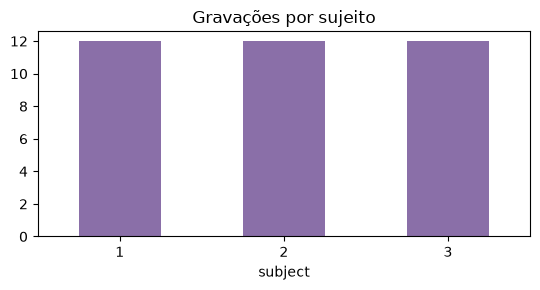

In [5]:
print("Sujeitos:", df_summary["subject"].nunique())
print("Sessões por sujeito:", df_summary.groupby("subject")["session"].nunique().unique())
print("Canais (EEG):", df_summary["n_eeg"].unique(), "| sfreq:", df_summary["sfreq_hz"].unique())
print("Duração total (min):", round(df_summary["duration_s"].sum() / 60, 1))

df_summary.groupby("subject").size().plot(
    kind="bar", color=PALETTE[1], rot=0, title="Gravações por sujeito", figsize=(5.5, 3))
plt.tight_layout()
plt.show()

## Distribuição das classes

As classes são recuperadas via janelamento por eventos (rótulo por trial). O 2a é balanceado por desenho: 12 trials/classe × 6 runs = 72 por classe por sessão.

Total de trials na amostra: 1728


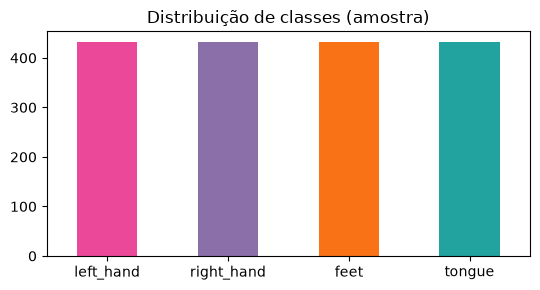

left_hand     432
right_hand    432
feet          432
tongue        432
Name: count, dtype: int64


In [6]:
CLASS_MAP = {"left_hand": 0, "right_hand": 1, "feet": 2, "tongue": 3}
windows = create_windows_from_events(
    dataset, trial_start_offset_samples=0, trial_stop_offset_samples=0,
    preload=False, mapping=CLASS_MAP)

# Rótulos direto dos metadados (sem carregar o sinal).
labels = np.concatenate([w.metadata["target"].to_numpy() for w in windows.datasets])
name_by_target = {v: k for k, v in CLASS_MAP.items()}

counts = pd.Series(labels).value_counts().sort_index()
counts.index = [name_by_target[i] for i in counts.index]
print("Total de trials na amostra:", len(labels))

counts.plot(kind="bar", color=PALETTE, rot=0,
            title="Distribuição de classes (amostra)", figsize=(5.5, 3))
plt.tight_layout()
plt.show()
print(counts)

## Sinal bruto

Trecho dos canais motores (C3/Cz/C4), onde a modulação sensório-motora da imagética é mais forte.

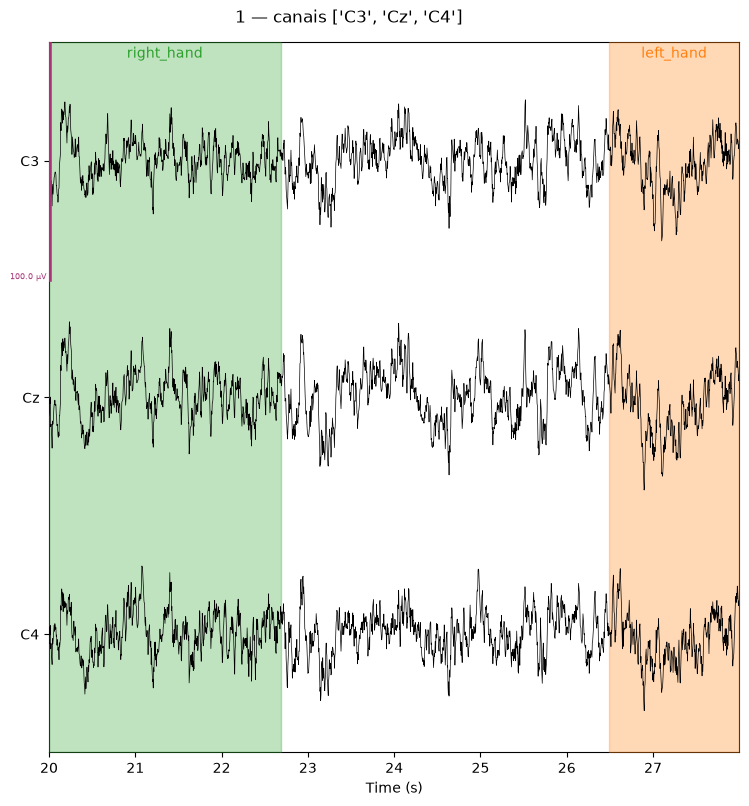

In [7]:
raw0 = dataset.datasets[0].raw
motor = [ch for ch in ["C3", "Cz", "C4"] if ch in raw0.ch_names]
if not motor:  # fallback caso os nomes venham diferentes
    motor = [raw0.ch_names[i] for i in mne.pick_types(raw0.info, eeg=True)[:3]]

fig = raw0.copy().pick(motor).plot(
    duration=8, start=20, scalings=dict(eeg=50e-6),
    show=False, show_scrollbars=False)
fig.suptitle(f"{dataset.datasets[0].description['subject']} — canais {motor}", y=1.01)
plt.show()